<a href="https://colab.research.google.com/github/navi1912/Advanced-Customer-Churning-Analysis/blob/main/Copy_of_Customer_Churn_Complete_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Behaviour Analytics & Churn Forecasting

This notebook builds a complete portfolio prototype:

**six relational tables → EDA → churn label → 28 customer-level features → baseline → XGBoost → evaluation → SHAP → business actions**

**Prediction cutoff:** 2025-09-30  
**Churn definition:** no successful purchase in the following 90 days.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_project.zip to customer_churn_project.zip


In [ ]:
!unzip -q customer_churn_project.zip

In [ ]:
!ls

customer_churn_project	customer_churn_project.zip  sample_data


In [ ]:
!ls customer_churn_project/data

customers.csv  products.csv		 transaction_items.csv
payments.csv   support_interactions.csv  transactions.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score, confusion_matrix,
    classification_report
)
from xgboost import XGBClassifier

# If SHAP is missing in your Colab runtime:
# !pip -q install shap
import shap

## Load the six relational tables

The folder `customer_churn_project` should already be extracted in the Colab working directory.

In [ ]:
BASE = "customer_churn_project/data"

customers = pd.read_csv(f"{BASE}/customers.csv")
transactions = pd.read_csv(f"{BASE}/transactions.csv")
transaction_items = pd.read_csv(f"{BASE}/transaction_items.csv")
products = pd.read_csv(f"{BASE}/products.csv")
payments = pd.read_csv(f"{BASE}/payments.csv")
support = pd.read_csv(f"{BASE}/support_interactions.csv")

customers["signup_date"] = pd.to_datetime(customers["signup_date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
support["interaction_date"] = pd.to_datetime(support["interaction_date"])

for name, df in {
    "customers": customers,
    "transactions": transactions,
    "transaction_items": transaction_items,
    "products": products,
    "payments": payments,
    "support": support
}.items():
    print(name, df.shape)

customers (8000, 4)
transactions (101435, 5)
transaction_items (101435, 5)
products (250, 3)
payments (101435, 4)
support (12025, 5)


## Basic EDA and data-quality checks

In [ ]:
print("Customer duplicate rows:", customers.duplicated().sum())
print("Transaction duplicate rows:", transactions.duplicated().sum())
print("Unique customer IDs:", customers["customer_id"].nunique())
print("Unique transaction IDs:", transactions["transaction_id"].nunique())

print("\nTransaction missing values:")
print(transactions.isna().sum())

print("\nPayment status:")
print(payments["payment_status"].value_counts())

print("\nTransaction date range:")
print(transactions["transaction_date"].min(), "to", transactions["transaction_date"].max())

Customer duplicate rows: 0
Transaction duplicate rows: 0
Unique customer IDs: 8000
Unique transaction IDs: 101435

Transaction missing values:
transaction_id        0
customer_id           0
transaction_date      0
channel               0
transaction_amount    0
dtype: int64

Payment status:
payment_status
Success     97523
Failed       2332
Refunded     1580
Name: count, dtype: int64

Transaction date range:
2024-01-01 00:00:00 to 2025-12-29 00:00:00


## Define the prediction cutoff and churn label

Only data on or before the cutoff can become model features.  
The future 90-day period is used only to construct the target.

In [ ]:
cutoff_date = pd.Timestamp("2025-09-30")
label_end_date = pd.Timestamp("2025-12-29")

transactions_full = transactions.merge(
    payments[["transaction_id", "payment_status"]],
    on="transaction_id",
    how="left"
)

successful_transactions = transactions_full[
    transactions_full["payment_status"].eq("Success")
].copy()

historical_successful = successful_transactions[
    successful_transactions["transaction_date"] <= cutoff_date
].copy()

future_successful = successful_transactions[
    (successful_transactions["transaction_date"] > cutoff_date) &
    (successful_transactions["transaction_date"] <= label_end_date)
].copy()

future_counts = (
    future_successful.groupby("customer_id")
    .size()
    .reset_index(name="future_purchases_90d")
)

churn_labels = customers[["customer_id"]].merge(
    future_counts, on="customer_id", how="left"
)
churn_labels["future_purchases_90d"] = (
    churn_labels["future_purchases_90d"].fillna(0).astype(int)
)
churn_labels["churn"] = (
    churn_labels["future_purchases_90d"].eq(0).astype(int)
)

print(churn_labels["churn"].value_counts())
print((churn_labels["churn"].value_counts(normalize=True) * 100).round(2))

churn
0    5287
1    2713
Name: count, dtype: int64
churn
0    66.09
1    33.91
Name: proportion, dtype: float64


## Build 28 behavioural features

The feature groups are RFM, purchase timing, recent-window activity, trend, channel/product behaviour, payments, support, and cohort retention.

In [ ]:
h = historical_successful.sort_values(
    ["customer_id", "transaction_date", "transaction_id"]
).copy()

# ---- Core RFM / lifetime behaviour ----
base_agg = (
    h.groupby("customer_id")
    .agg(
        last_purchase_date=("transaction_date", "max"),
        first_purchase_date=("transaction_date", "min"),
        frequency=("transaction_id", "nunique"),
        monetary=("transaction_amount", "sum"),
        avg_order_value=("transaction_amount", "mean"),
        std_order_value=("transaction_amount", "std"),
    )
    .reset_index()
)

base_agg["recency_days"] = (
    cutoff_date - base_agg["last_purchase_date"]
).dt.days

base_agg["days_since_first_purchase"] = (
    cutoff_date - base_agg["first_purchase_date"]
).dt.days

base_agg["active_span_days"] = (
    base_agg["last_purchase_date"] - base_agg["first_purchase_date"]
).dt.days

# ---- Purchase gaps using shift() = Pandas equivalent of SQL LAG ----
h["previous_purchase_date"] = (
    h.groupby("customer_id")["transaction_date"].shift(1)
)
h["gap_days"] = (
    h["transaction_date"] - h["previous_purchase_date"]
).dt.days

gap_features = (
    h.groupby("customer_id")
    .agg(
        avg_purchase_gap_days=("gap_days", "mean"),
        std_purchase_gap_days=("gap_days", "std")
    )
    .reset_index()
)

# ---- Rolling average of the latest 3 orders ----
h["rolling_3_order_avg"] = (
    h.groupby("customer_id")["transaction_amount"]
    .transform(lambda s: s.rolling(3, min_periods=1).mean())
)
rolling_feature = (
    h.groupby("customer_id").tail(1)
    [["customer_id", "rolling_3_order_avg"]]
)

# ---- Recent activity windows ----
def activity_window(days, suffix):
    w = h[
        (h["transaction_date"] > cutoff_date - pd.Timedelta(days=days)) &
        (h["transaction_date"] <= cutoff_date)
    ]
    return (
        w.groupby("customer_id")
        .agg(
            **{
                f"purchases_{suffix}": ("transaction_id", "nunique"),
                f"spend_{suffix}": ("transaction_amount", "sum"),
                f"avg_order_{suffix}": ("transaction_amount", "mean"),
            }
        )
        .reset_index()
    )

w30 = activity_window(30, "30d")
w90 = activity_window(90, "90d")

# Previous 90 days, used for trend comparison
previous_90 = h[
    (h["transaction_date"] > cutoff_date - pd.Timedelta(days=180)) &
    (h["transaction_date"] <= cutoff_date - pd.Timedelta(days=90))
]

previous_90 = (
    previous_90.groupby("customer_id")
    .agg(
        purchases_prev_90d=("transaction_id", "nunique"),
        spend_prev_90d=("transaction_amount", "sum")
    )
    .reset_index()
)

# ---- Channel behaviour ----
channel_counts = (
    h.groupby(["customer_id", "channel"])
    .size()
    .unstack(fill_value=0)
)
channel_total = channel_counts.sum(axis=1)

channel_features = pd.DataFrame({
    "customer_id": channel_counts.index,
    "mobile_share": (
        channel_counts.get("Mobile", 0) / channel_total
    ).values
})

# ---- Product category diversity ----
item_category = (
    h[["transaction_id", "customer_id"]]
    .merge(
        transaction_items[["transaction_id", "product_id"]],
        on="transaction_id",
        how="left"
    )
    .merge(
        products[["product_id", "category"]],
        on="product_id",
        how="left"
    )
)

category_features = (
    item_category.groupby("customer_id")["category"]
    .nunique()
    .reset_index(name="category_diversity")
)

# ---- Payment behaviour from all historical attempts ----
all_historical_attempts = transactions_full[
    transactions_full["transaction_date"] <= cutoff_date
].copy()

payment_counts = pd.crosstab(
    all_historical_attempts["customer_id"],
    all_historical_attempts["payment_status"]
)
payment_total = payment_counts.sum(axis=1)

payment_features = pd.DataFrame({
    "customer_id": payment_counts.index,
    "failed_payment_rate": (
        payment_counts.get("Failed", 0) / payment_total
    ).values,
    "refund_rate": (
        payment_counts.get("Refunded", 0) / payment_total
    ).values
})

# ---- Support behaviour ----
historical_support = support[
    support["interaction_date"] <= cutoff_date
].copy()

support_90 = (
    historical_support[
        historical_support["interaction_date"] >
        cutoff_date - pd.Timedelta(days=90)
    ]
    .groupby("customer_id")
    .size()
    .reset_index(name="support_contacts_90d")
)

support_avg = (
    historical_support.groupby("customer_id")["satisfaction_score"]
    .mean()
    .reset_index(name="avg_satisfaction")
)

# ---- Historical cohort retention ----
cohort = customers[["customer_id", "signup_date"]].copy()
cohort["signup_cohort"] = cohort["signup_date"].dt.to_period("M").astype(str)

active_last_90 = (
    h[h["transaction_date"] > cutoff_date - pd.Timedelta(days=90)]
    .groupby("customer_id")
    .size()
    .gt(0)
    .reset_index(name="active_90d")
)

cohort = cohort.merge(active_last_90, on="customer_id", how="left")
cohort["active_90d"] = cohort["active_90d"].fillna(False)

cohort_rates = (
    cohort.groupby("signup_cohort")["active_90d"]
    .mean()
    .reset_index(name="cohort_retention_90d")
)

cohort_feature = (
    cohort[["customer_id", "signup_cohort"]]
    .merge(cohort_rates, on="signup_cohort", how="left")
    [["customer_id", "cohort_retention_90d"]]
)

# ---- Combine everything to one row per customer ----
model_data = customers[["customer_id", "signup_date"]].copy()
model_data["tenure_days"] = (
    cutoff_date - model_data["signup_date"]
).dt.days

for frame in [
    base_agg,
    gap_features,
    rolling_feature,
    w30,
    w90,
    previous_90,
    channel_features,
    category_features,
    payment_features,
    support_90,
    support_avg,
    cohort_feature
]:
    model_data = model_data.merge(frame, on="customer_id", how="left")

model_data["purchase_trend_ratio_90d"] = (
    model_data["purchases_90d"] /
    (model_data["purchases_prev_90d"].fillna(0) + 1)
)

model_data["spend_trend_ratio_90d"] = (
    model_data["spend_90d"] /
    (model_data["spend_prev_90d"].fillna(0) + 1)
)

model_data = model_data.merge(
    churn_labels[["customer_id", "future_purchases_90d", "churn"]],
    on="customer_id",
    how="left"
)

/tmp/ipykernel_3550/3082667376.py:185: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cohort["active_90d"] = cohort["active_90d"].fillna(False)


## Select exactly 28 engineered features

`future_purchases_90d` is deliberately excluded because it was used to construct the target and would cause leakage.

In [ ]:
feature_cols = [
    "tenure_days",
    "recency_days",
    "frequency",
    "monetary",
    "avg_order_value",
    "std_order_value",
    "rolling_3_order_avg",
    "days_since_first_purchase",
    "active_span_days",
    "avg_purchase_gap_days",
    "std_purchase_gap_days",
    "purchases_30d",
    "purchases_90d",
    "spend_30d",
    "spend_90d",
    "avg_order_30d",
    "avg_order_90d",
    "purchases_prev_90d",
    "spend_prev_90d",
    "purchase_trend_ratio_90d",
    "spend_trend_ratio_90d",
    "mobile_share",
    "category_diversity",
    "failed_payment_rate",
    "refund_rate",
    "support_contacts_90d",
    "avg_satisfaction",
    "cohort_retention_90d",
]

print("Number of engineered features:", len(feature_cols))

# Missing recent activity means zero activity.
# For satisfaction, use the historical median rather than inventing a 0 on a 1-5 scale.
median_satisfaction = model_data["avg_satisfaction"].median()

for col in feature_cols:
    if col == "avg_satisfaction":
        model_data[col] = model_data[col].fillna(median_satisfaction)
    else:
        model_data[col] = model_data[col].fillna(0)

print("Remaining feature nulls:", model_data[feature_cols].isna().sum().sum())
model_data[["customer_id"] + feature_cols + ["churn"]].head()

Number of engineered features: 28
Remaining feature nulls: 0


,customer_id,tenure_days,recency_days,frequency,monetary,avg_order_value,std_order_value,rolling_3_order_avg,days_since_first_purchase,active_span_days,...,purchase_trend_ratio_90d,spend_trend_ratio_90d,mobile_share,category_diversity,failed_payment_rate,refund_rate,support_contacts_90d,avg_satisfaction,cohort_retention_90d,churn
0,100001,228,124,6,10171.85,1695.308333,592.283139,1756.046667,174,50,...,0.000000,0.000000,0.333333,4,0.0,0.000000,1.0,3.000000,0.762846,1
1,100002,490,184,12,17993.88,1499.490000,1358.315686,957.980000,467,283,...,0.000000,0.000000,0.583333,6,0.0,0.000000,0.0,2.000000,0.658065,1
2,100003,442,16,17,22332.63,1313.684118,853.726718,2023.413333,428,412,...,0.750000,1.690592,0.294118,5,0.0,0.000000,0.0,3.666667,0.613333,0
3,100004,267,1,14,23041.71,1645.836429,1236.959134,889.406667,178,177,...,0.666667,0.562020,0.571429,5,0.0,0.000000,0.0,4.333333,0.701342,0
4,100005,529,225,8,21580.95,2697.618750,4044.293355,5169.366667,430,205,...,0.000000,0.000000,0.125000,4,0.0,0.111111,0.0,4.000000,0.582090,1


## Quick behavioural EDA by churn class

In [ ]:
eda_compare = (
    model_data.groupby("churn")[
        [
            "recency_days", "frequency", "monetary",
            "purchases_90d", "support_contacts_90d",
            "avg_satisfaction"
        ]
    ]
    .mean()
    .round(2)
)

eda_compare

,recency_days,frequency,monetary,purchases_90d,support_contacts_90d,avg_satisfaction
churn,,,,,,
0,46.25,11.06,20731.65,2.20,0.17,3.63
1,176.69,7.50,14044.46,0.18,0.30,2.62


## Train/test split

For this single-cutoff synthetic prototype we use an 80/20 stratified split.  
For real deployment, rolling temporal validation across multiple historical cutoffs would be stronger.

In [ ]:
X = model_data[feature_cols]
y = model_data["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

(6400, 28) (1600, 28)
churn
0    0.661
1    0.339
Name: proportion, dtype: float64
churn
0    0.661
1    0.339
Name: proportion, dtype: float64


## Baseline: Logistic Regression

A baseline proves that a more complex model is actually useful.

In [ ]:
baseline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced")
)

baseline.fit(X_train, y_train)

baseline_prob = baseline.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_prob >= 0.5).astype(int)

print("Baseline ROC-AUC:", round(roc_auc_score(y_test, baseline_prob), 4))
print("Baseline F1:", round(f1_score(y_test, baseline_pred), 4))

Baseline ROC-AUC: 0.9638
Baseline F1: 0.8592


## XGBoost model

In [ ]:
model = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

churn_probability = model.predict_proba(X_test)[:, 1]
prediction = (churn_probability >= 0.5).astype(int)

print("ROC-AUC:", round(roc_auc_score(y_test, churn_probability), 4))
print("F1:", round(f1_score(y_test, prediction), 4))
print("Precision:", round(precision_score(y_test, prediction), 4))
print("Recall:", round(recall_score(y_test, prediction), 4))
print("Accuracy:", round(accuracy_score(y_test, prediction), 4))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, prediction))
print("\nClassification report:")
print(classification_report(y_test, prediction))

ROC-AUC: 0.9714
F1: 0.8625
Precision: 0.8705
Recall: 0.8545
Accuracy: 0.9075

Confusion matrix:
[[988  69]
 [ 79 464]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1057
           1       0.87      0.85      0.86       543

    accuracy                           0.91      1600
   macro avg       0.90      0.89      0.90      1600
weighted avg       0.91      0.91      0.91      1600



## SHAP explainability

Global SHAP importance answers: **which features matter most overall?**  
Local SHAP values answer: **why was this specific customer scored as high risk?**

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

global_importance = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

global_importance.head(10)

,0
recency_days,2.431312
avg_satisfaction,0.748706
active_span_days,0.322765
purchases_30d,0.208958
purchase_trend_ratio_90d,0.174979
failed_payment_rate,0.171413
tenure_days,0.171153
avg_purchase_gap_days,0.166526
refund_rate,0.140184
spend_prev_90d,0.128540


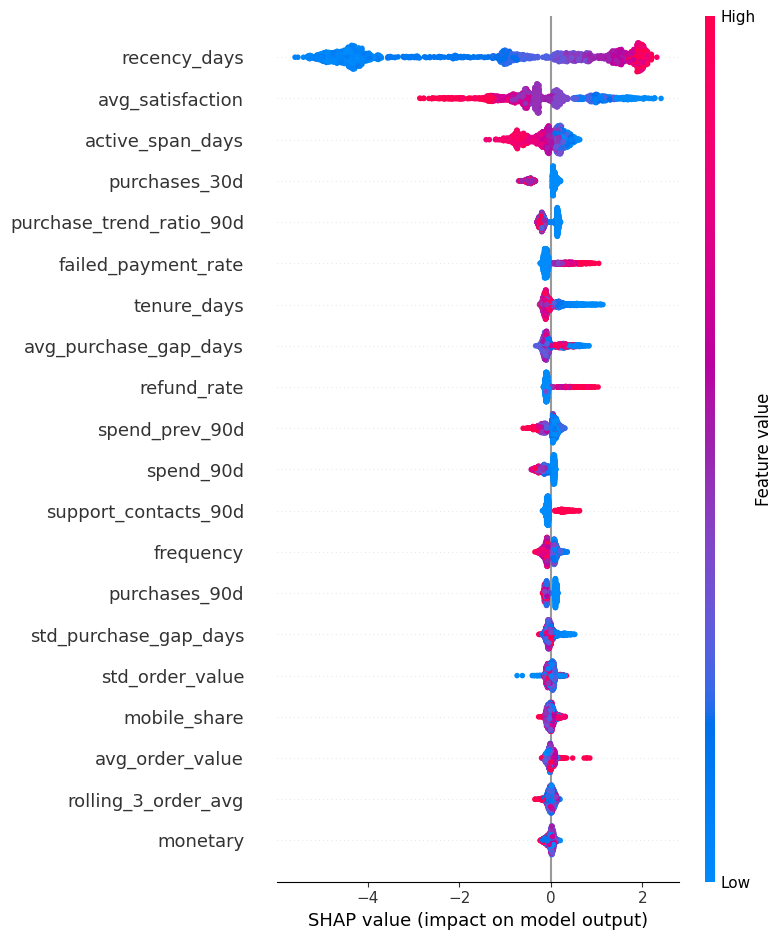

In [ ]:
shap.summary_plot(
    shap_values.values,
    X_test,
    feature_names=feature_cols
)

## Create an actionable customer-risk table

In [ ]:
results = X_test.copy()
results["actual_churn"] = y_test.values
results["churn_probability"] = churn_probability
results["predicted_churn"] = prediction
results["customer_id"] = model_data.loc[X_test.index, "customer_id"].values

results = results.sort_values("churn_probability", ascending=False)

results[
    [
        "customer_id", "churn_probability",
        "recency_days", "frequency",
        "purchases_90d", "support_contacts_90d",
        "avg_satisfaction"
    ]
].head(20)

,customer_id,churn_probability,recency_days,frequency,purchases_90d,support_contacts_90d,avg_satisfaction
2269,102270,0.998434,209,6,0.0,1.0,1.000000
786,100787,0.998254,205,8,0.0,2.0,1.666667
4284,104285,0.998111,213,9,0.0,0.0,2.000000
3233,103234,0.996710,239,6,0.0,1.0,1.333333
706,100707,0.996566,181,9,0.0,0.0,1.500000
5502,105503,0.996524,202,5,0.0,0.0,2.000000
5104,105105,0.996117,199,10,0.0,1.0,2.333333
2332,102333,0.995980,179,8,0.0,0.0,2.000000
662,100663,0.994883,192,5,0.0,0.0,2.000000
1764,101765,0.994314,137,15,0.0,2.0,2.000000


## Example business rule

The model predicts risk; the intervention depends on the dominant driver.

- Long inactivity / low recent purchases → reactivation offer.
- Poor satisfaction / repeated support contacts → service recovery.
- Declining spend → personalized recommendation or loyalty incentive.

In [ ]:
def recommended_action(row):
    if row["support_contacts_90d"] >= 2 and row["avg_satisfaction"] < 3:
        return "Service recovery / priority support"
    if row["recency_days"] >= 60:
        return "Reactivation offer"
    if row["purchases_90d"] == 0:
        return "Personalized win-back campaign"
    return "Monitor / personalized recommendation"

results["recommended_action"] = results.apply(recommended_action, axis=1)

results[
    ["customer_id", "churn_probability", "recommended_action"]
].head(20)

,customer_id,churn_probability,recommended_action
2269,102270,0.998434,Reactivation offer
786,100787,0.998254,Service recovery / priority support
4284,104285,0.998111,Reactivation offer
3233,103234,0.996710,Reactivation offer
706,100707,0.996566,Reactivation offer
5502,105503,0.996524,Reactivation offer
5104,105105,0.996117,Reactivation offer
2332,102333,0.995980,Reactivation offer
662,100663,0.994883,Reactivation offer
1764,101765,0.994314,Service recovery / priority support


## Save final outputs

In [ ]:
final_features = model_data[
    ["customer_id"] + feature_cols + ["churn"]
].copy()

final_features.to_csv("customer_features_28.csv", index=False)
results.to_csv("customer_churn_predictions.csv", index=False)

print("Saved customer_features_28.csv")
print("Saved customer_churn_predictions.csv")

Saved customer_features_28.csv
Saved customer_churn_predictions.csv
